#  Customer Churn Prediction Project

# 1- Business Understanding

##  Project Overview

Customer churn is one of the most important business problems for subscription-based companies such as telecom providers, internet services, banks, insurance companies, and SaaS businesses.

Customer churn occurs when a customer decides to stop using a company’s services. High churn rates can significantly reduce revenue and profitability because acquiring new customers is often much more expensive than retaining existing ones.

In this project, we will analyze customer data from a telecom company in order to identify the main factors that contribute to customer churn and build machine learning models capable of predicting whether a customer is likely to leave the company.

---

#  Business Problem

The company wants to answer the following question:

> **Which customers are likely to churn and what factors influence their decision to leave?**

By predicting churn in advance, the company can proactively take actions such as:

- offering promotions or discounts
- improving customer support
- creating loyalty programs
- targeting high-risk customers with retention campaigns

Reducing churn can help the company:

- increase long-term revenue
- improve customer satisfaction
- reduce customer acquisition costs
- improve business stability

---

#  Machine Learning Problem Type

This project is a:

##  Supervised Machine Learning Problem

because we already know the historical outcomes (customers who churned and customers who stayed).

More specifically, this is a:

##  Binary Classification Problem

The target variable is:

| Churn Status | Meaning |
|---|---|
| Yes | Customer left the company |
| No | Customer stayed |

The model will learn patterns from historical customer data in order to predict future churn behavior.

---

#  Dataset Information

The dataset contains information about telecom customers including:

- demographic information
- account details
- subscribed services
- billing information
- contract types
- payment methods
- internet services
- customer tenure

The dataset also includes the target column:

## `Churn`

which indicates whether the customer left the company or not.

---

#  Planned Workflow

The project will follow a complete end-to-end data science workflow:

1. Business Understanding
2. Data Loading and Exploration
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Feature Engineering
6. Data Preprocessing
7. Model Building
8. Model Evaluation
9. Model Comparison
10. Business Conclusions and Recommendations

---


#  Expected Business Value

By accurately identifying customers at high risk of churning, the company can:

- improve customer retention
- optimize marketing efforts
- reduce revenue loss
- improve customer lifetime value
- make more data-driven business decisions

---

#  Technologies & Libraries

This project will primarily use:

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- TensorFlow / Keras

---

#  Final Deliverables

At the end of the project, we aim to produce:

- a complete exploratory analysis
- multiple predictive machine learning models
- model performance comparisons
- visualizations and insights
- final business recommendations
- a professional GitHub-ready portfolio project

# 2- Imports & Environment Setup

In this section, we will import all the necessary Python libraries required for data manipulation, visualization, machine learning, and model evaluation.

We will also configure some notebook settings to improve readability and visualization quality throughout the project.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
sns.set_style('whitegrid')

In [267]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
# Notebook Configuration:
import warnings
warnings.filterwarnings('ignore')

# 3- Data loading & Initial Exploration

In [10]:
# loading and reading the data:
cust_data = pd.read_excel('../Data/Telco_customer_churn.xlsx')

In [11]:
cust_data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [12]:
cust_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

we can tell that there are some columns with wrong data types like Total charge for exemple (we should convert it from string to float), will deal with this later

In [17]:
#checking the size and shae of the datasets:
cust_data.shape

(7043, 33)

we can tell that the data set is not very big , but has a segnificant amount of features we can use.

In [14]:
cust_data.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [18]:
# checking the columns thtaare not numeric
cust_data.select_dtypes(exclude='number').columns

Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges', 'Churn Label', 'Churn Reason'],
      dtype='object')

We have a lot of categrical ad text type column we will deal with them and feature them later in the preprocessing section

In [20]:
# checking for missing values:
cust_data.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

its seemes that we dont really have missing values exept for Churn Reason, we will also deal with that later.

In [21]:
## Some statistical Summary:
cust_data.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [22]:
## Categorical Summary :
cust_data.describe(include='object')

,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.0,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,2,4,6531.0,2,20
top,3668-QPYBK,United States,California,Los Angeles,"33.964131, -118.272783",Male,No,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3095,3473,2810,2785,3875,4171,2365,11.0,5174,192


from this initial check we can say we hve some importnt caegorical columns we should change to numeric using one-hot encoding , and some like country seems to be one country so it will be useless, anyway we will deal with the feature in the preproseesing section in depth.

In [23]:
## checking for duplicates:
cust_data.duplicated().sum()

np.int64(0)

thats good, we have no duplicates in the dataset

# 4- Exploratory Data Analysis (EDA):

# 4.1- Target(Label) Variable Analysis:

<Axes: xlabel='Churn Label', ylabel='count'>

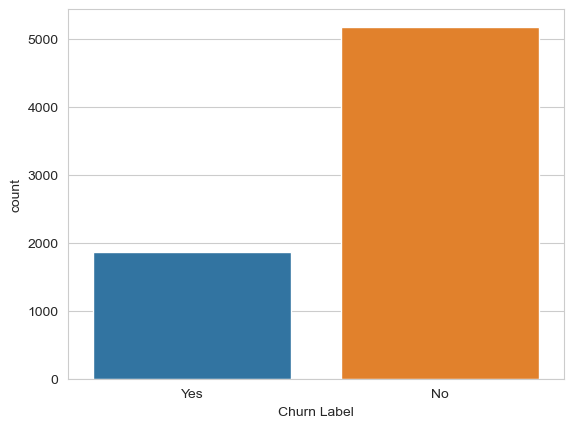

In [25]:
sns.countplot(data=cust_data, x='Churn Label', hue='Churn Label')

In [28]:
cust_data['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [29]:
cust_data['Churn Label'].value_counts(normalize=True)*100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

We can observe that the Dataset appears moderately imbalanced, with significantly more non-churm customers (73.50%) than Churm customers (23.50%)

# 4.2- Numerical Features Analysis :

In [35]:
# Those are three important continuious numerical features:
cust_data[['Tenure Months', 'Monthly Charges', 'Total Charges']].head()

,Tenure Months,Monthly Charges,Total Charges
0,2,53.85,108.15
1,2,70.70,151.65
2,8,99.65,820.5
3,28,104.80,3046.05
4,49,103.70,5036.3


<Axes: xlabel='Tenure Months', ylabel='Count'>

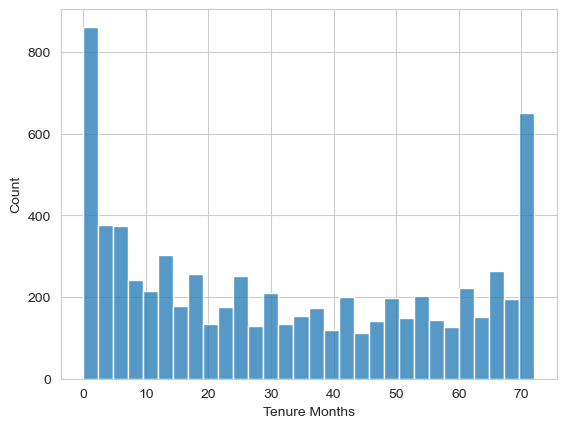

In [39]:
sns.histplot(data=cust_data, x='Tenure Months', bins=30)

<Axes: xlabel='Tenure Months', ylabel='Count'>

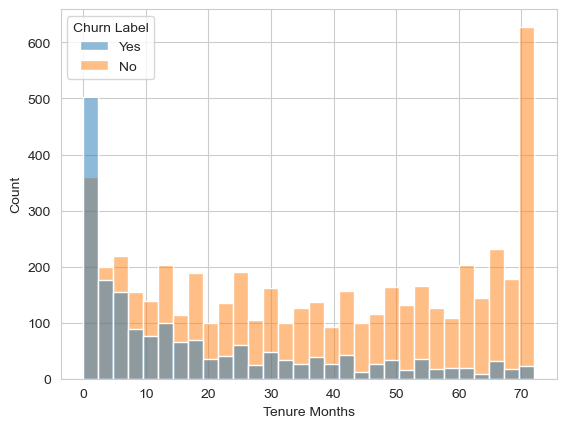

In [41]:
sns.histplot(data=cust_data, x='Tenure Months', bins=30, hue='Churn Label')

<Axes: xlabel='Tenure Months', ylabel='Density'>

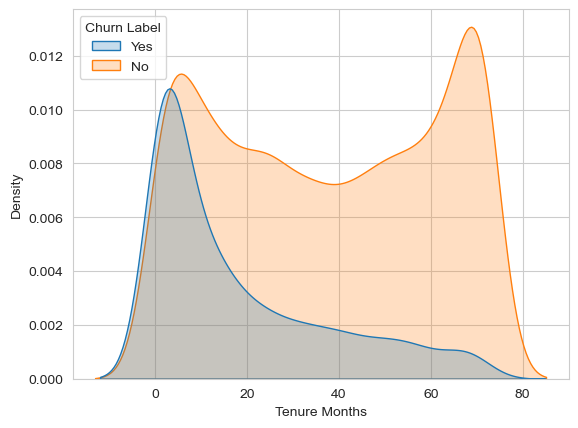

In [46]:
sns.kdeplot(data=cust_data, x='Tenure Months', hue='Churn Label', fill=True)

- we have unnormal distrubution of tenure months and maybe some outliers here in very low and very high months.
- but most importanttly we can see that customers with low and newly subscribed tend to churn most of the time comparing to people with long duration subscribtion tent to stay with company (very logical).
- we ca see that slong as the customer stay subscribe, the low propability he is going to churn. 

<Axes: xlabel='Monthly Charges', ylabel='Count'>

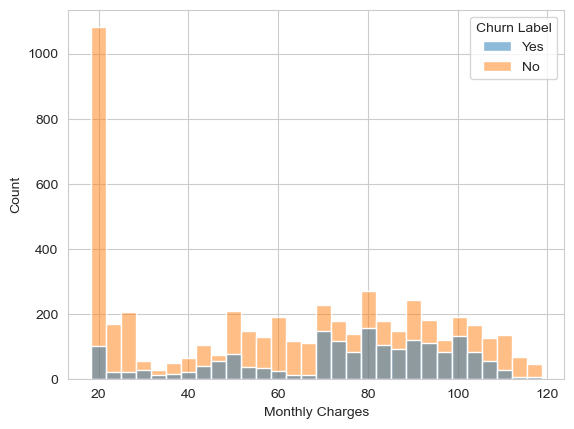

In [51]:
# Monthly Charges:
sns.histplot(data=cust_data, x='Monthly Charges', hue='Churn Label', bins=30)

<Axes: xlabel='Churn Label', ylabel='Monthly Charges'>

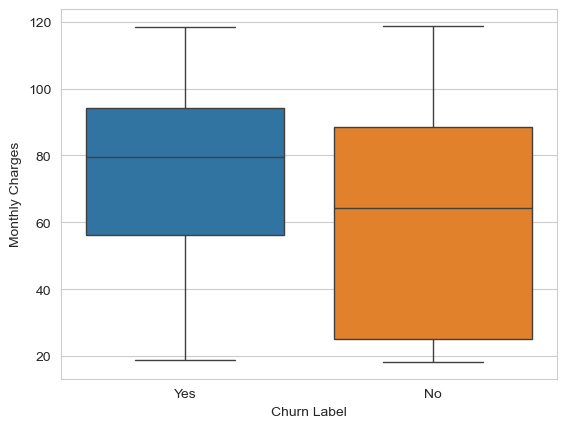

In [53]:
sns.boxplot(data=cust_data, x='Churn Label', y='Monthly Charges', hue='Churn Label')

- we can see that most of the customers have a low fee or monthly charges and fewer has the high subscribtion plan.
- more importantly we can observe that customers with higher monthly charges tend to churn a lot more than customer that pay the minimum fees,
  which may lead us to think that the higher subscription plans has low quality/price ratio. 

In [61]:
# Total charges:
# we need to change Total charge type to float so we can plot it as continues value:
cust_data['Total Charges'].value_counts()

Total Charges
20.2      11
          11
19.75      9
19.65      8
20.05      8
          ..
444.75     1
5459.2     1
295.95     1
394.1      1
6844.5     1
Name: count, Length: 6531, dtype: int64

- very important notice: we see that the total charges is string type , also they are somme rows that have value of ' ' (Empty String), so when we try to convert ' ' string to float it gives us error.
- so we are going to use the to_numeric method of pandas with the aram error that will convert ' ' to NaN value.
- and later we will also deal with the missing data that we dscover now.

In [62]:
cust_data['Total Charges'] = pd.to_numeric(cust_data['Total Charges'], errors='coerce')

In [63]:
print(cust_data['Total Charges'].dtype)

float64


We successfuly convert the type of Total Charges to float, now we can plot it as we want.

<Axes: xlabel='Total Charges', ylabel='Count'>

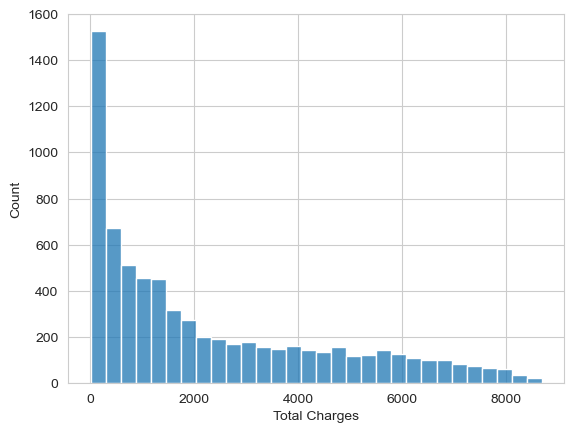

In [65]:
sns.histplot(data=cust_data, x='Total Charges', bins=30)

<Axes: xlabel='Total Charges', ylabel='Count'>

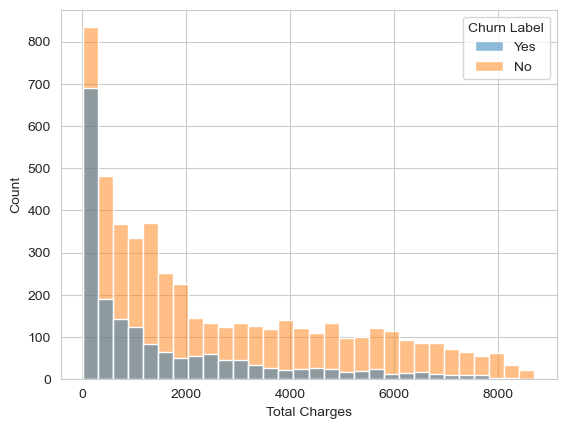

In [66]:
sns.histplot(data=cust_data, x='Total Charges', bins=30, hue='Churn Label')

- we can abviously notice that most of the customers have lower total charges.
- and the one that have the lower total charge are the one that tend to churn at the end of the quarter, which may lead us to think thatthe people who just started and didnt like the offer or product tend to quite quickly.

# 4.3- Categorical Features Analysis :

In [72]:
# most important categorical feature to look into :
cust_data[['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method', 'Paperless Billing']].head()

,Gender,Senior Citizen,Partner,Dependents,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Payment Method,Paperless Billing
0,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Mailed check,Yes
1,Female,No,No,Yes,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check,Yes
2,Female,No,No,Yes,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Electronic check,Yes
3,Female,No,Yes,Yes,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Electronic check,Yes
4,Male,No,No,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Bank transfer (automatic),Yes


<Axes: xlabel='Contract', ylabel='count'>

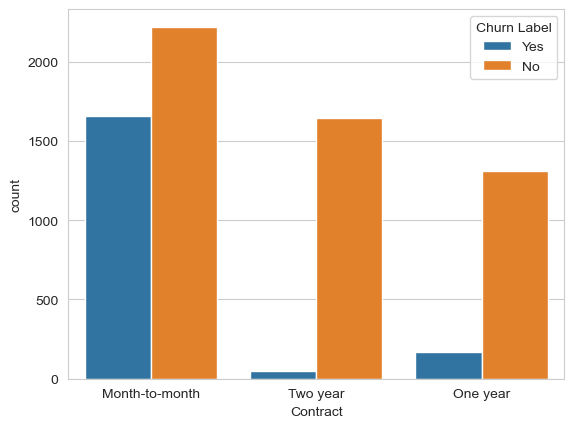

In [73]:
## now we analyse some of the important onces: 
# 1- Contract :
sns.countplot(data=cust_data, x='Contract', hue='Churn Label')

In [78]:
# better result with this :
cust_data.groupby('Contract')['Churn Label'].value_counts(normalize=True)*100

Contract        Churn Label
Month-to-month  No             57.290323
                Yes            42.709677
One year        No             88.730482
                Yes            11.269518
Two year        No             97.168142
                Yes             2.831858
Name: proportion, dtype: float64

- first observation : is that the customer with month-to-month contarct have almost 50% probability to churn at the end, compare to the other type of contract.
- Customers with month-to-month contracts exhibit significantly higher churn rates compared to customers with long-term contract.

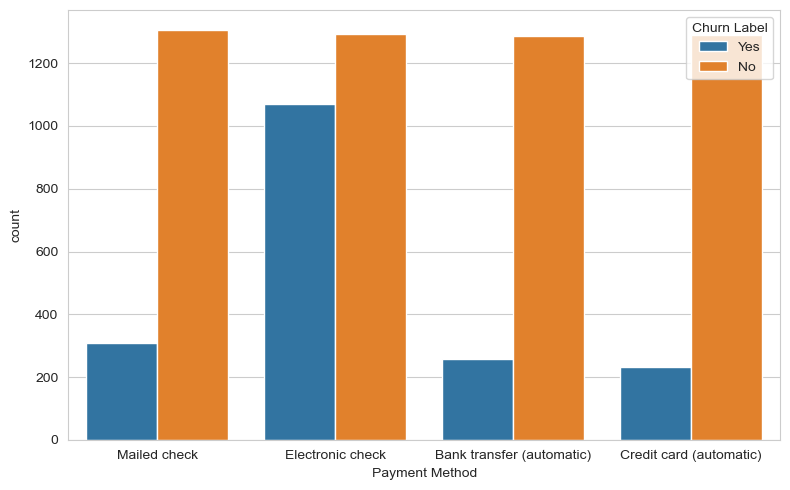

In [83]:
# 2- payment method :
plt.figure(figsize=(8,5))
sns.countplot(data=cust_data, x='Payment Method', hue='Churn Label')
plt.tight_layout()

In [84]:
cust_data.groupby('Payment Method')['Churn Label'].value_counts(normalize=True)*100

Payment Method             Churn Label
Bank transfer (automatic)  No             83.290155
                           Yes            16.709845
Credit card (automatic)    No             84.756899
                           Yes            15.243101
Electronic check           No             54.714588
                           Yes            45.285412
Mailed check               No             80.893300
                           Yes            19.106700
Name: proportion, dtype: float64

- first we can see that people with automatic payment like creadit card and bank transfert are more stable customers and
- Customers with manual Electronic check payement meethod exhibit significantly higher churn rates (almost 50% chance) compared to customers with autmatic renew payment method.
- which may lead us to think that people wont bother changing comapnies or offers if it's already done automaticaly.

<Axes: xlabel='Internet Service', ylabel='count'>

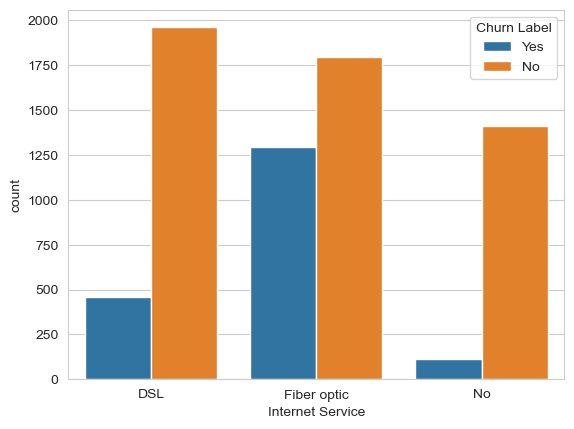

In [91]:
# 4- Internet Service:
sns.countplot(data=cust_data, x='Internet Service', hue='Churn Label')

In [88]:
cust_data.groupby('Internet Service')['Churn Label'].value_counts(normalize=True)*100

Internet Service  Churn Label
DSL               No             81.040892
                  Yes            18.959108
Fiber optic       No             58.107235
                  Yes            41.892765
No                No             92.595020
                  Yes             7.404980
Name: proportion, dtype: float64

- we can see that the customer with Inernet Service of Fiber Optic has the most churn rate.
- that's tell us that likly the Fiber offer are either not good or expensive for it's quality.
- it could be one of the important reasons 

<Axes: xlabel='Online Security', ylabel='count'>

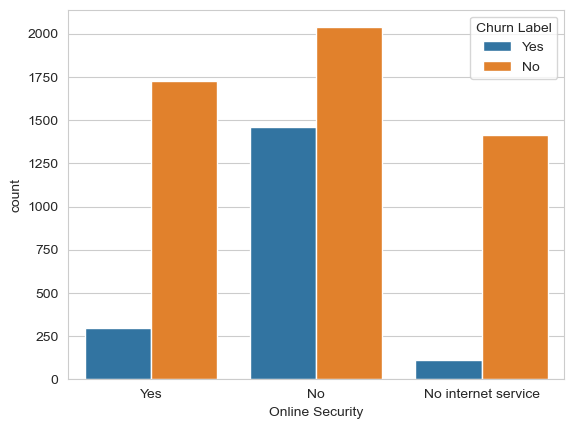

In [93]:
# 5- online Security:
sns.countplot(data=cust_data, x='Online Security', hue='Churn Label')

In [94]:
cust_data.groupby('Online Security')['Churn Label'].value_counts(normalize=True)*100

Online Security      Churn Label
No                   No             58.233276
                     Yes            41.766724
No internet service  No             92.595020
                     Yes             7.404980
Yes                  No             85.388806
                     Yes            14.611194
Name: proportion, dtype: float64

- Customers with online security exhibit significantly lower churn rates compared to customers with no online security.
- Means people with online security need this service and are more invested in the company than no online security.
- or the online security service is good

<Axes: xlabel='Online Backup', ylabel='count'>

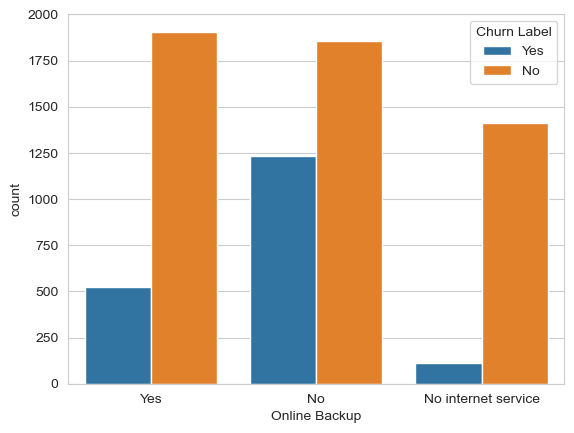

In [95]:
sns.countplot(data=cust_data, x='Online Backup', hue='Churn Label')

In [97]:
cust_data.groupby('Online Backup')['Churn Label'].value_counts(normalize=True)*100

Online Backup        Churn Label
No                   No             60.071244
                     Yes            39.928756
No internet service  No             92.595020
                     Yes             7.404980
Yes                  No             78.468506
                     Yes            21.531494
Name: proportion, dtype: float64

- we can also notice thata customer with subscription that include an online backup service have lower churn rate than the ones that haven't, which is logical cause the oe that have are more attached to the service and the company prviding it.

<Axes: xlabel='Device Protection', ylabel='count'>

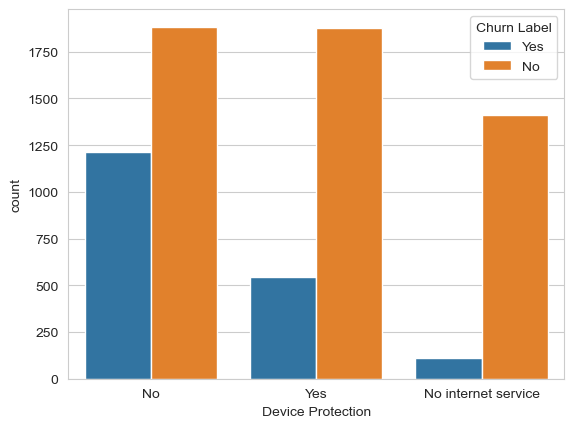

In [103]:
# Device Protection
sns.countplot(data=cust_data, x='Device Protection', hue='Churn Label')

- same observation as the previous for the device protection feature.

<Axes: xlabel='Tech Support', ylabel='count'>

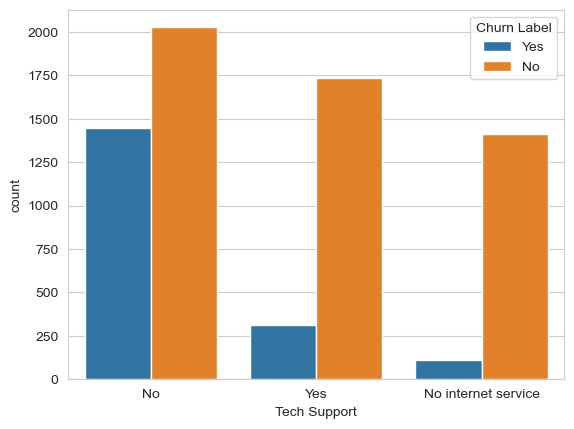

In [104]:
# Tech Support:
sns.countplot(data=cust_data, x='Tech Support', hue='Churn Label')

<Axes: xlabel='Gender', ylabel='count'>

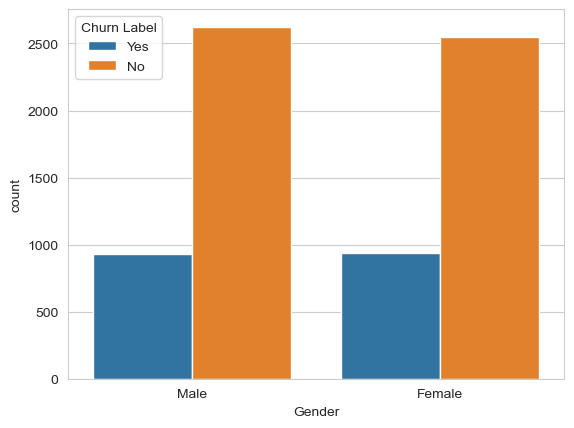

In [105]:
# Gender:
sns.countplot(data=cust_data, x='Gender' , hue='Churn Label')

- we can tell there is no effect or rate deferences between being male or female.

<Axes: xlabel='Dependents', ylabel='count'>

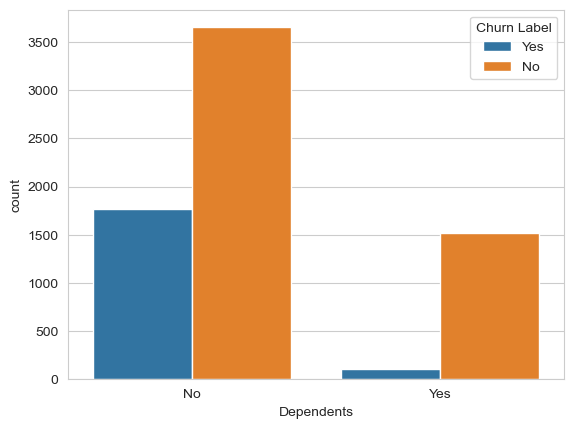

In [110]:
sns.countplot(data=cust_data, x='Dependents' , hue='Churn Label')

In [111]:
cust_data.groupby('Dependents')['Churn Label'].value_counts(normalize=True)*100

Dependents  Churn Label
No          No             67.448301
            Yes            32.551699
Yes         No             93.484942
            Yes             6.515058
Name: proportion, dtype: float64

- relatively customers that have or live with dependents like children and parent have lower rate of churn than the ones that live alone, and this is due to responsibilities, they are dependent to thier families for the decision like that. whene others needed it he won't close the offer even if the service do not satisfy him.

# 4- Correlation Analysis :

In [113]:
# correlation matrix
corr = cust_data.corr(numeric_only=True)
corr

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,NaN,1.000000,0.895743,-0.784271,0.001041,-0.004596,-0.001462,0.003346,-0.002769,-0.003562
Latitude,NaN,0.895743,1.000000,-0.876779,-0.001631,-0.019899,-0.010313,-0.003384,-0.007684,0.000886
Longitude,NaN,-0.784271,-0.876779,1.000000,-0.001678,0.024098,0.009047,0.004594,0.004260,0.000485
Tenure Months,NaN,0.001041,-0.001631,-0.001678,1.000000,0.247900,0.825880,-0.352229,-0.224987,0.396406
Monthly Charges,NaN,-0.004596,-0.019899,0.024098,0.247900,1.000000,0.651065,0.193356,0.133754,0.098693
Total Charges,NaN,-0.001462,-0.010313,0.009047,0.825880,0.651065,1.000000,-0.199484,-0.124312,0.341837
Churn Value,NaN,0.003346,-0.003384,0.004594,-0.352229,0.193356,-0.199484,1.000000,0.664897,-0.127463
Churn Score,NaN,-0.002769,-0.007684,0.004260,-0.224987,0.133754,-0.124312,0.664897,1.000000,-0.079782
CLTV,NaN,-0.003562,0.000886,0.000485,0.396406,0.098693,0.341837,-0.127463,-0.079782,1.000000


<Axes: >

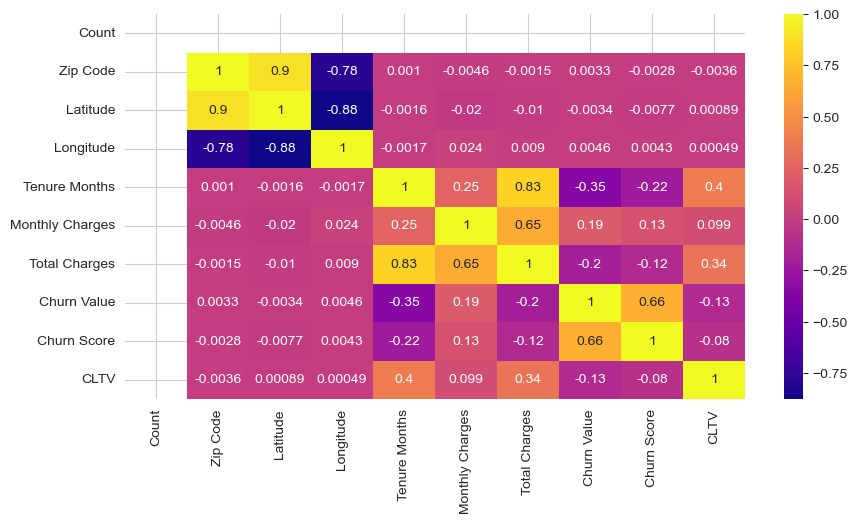

In [115]:
plt.figure(figsize=(10,5))
sns.heatmap(data=corr, cmap='plasma', annot=True)

we can see tha the there is no really important correlation, except  zip code with latitude and longitude which is logical.

<Axes: xlabel='Latitude', ylabel='Longitude'>

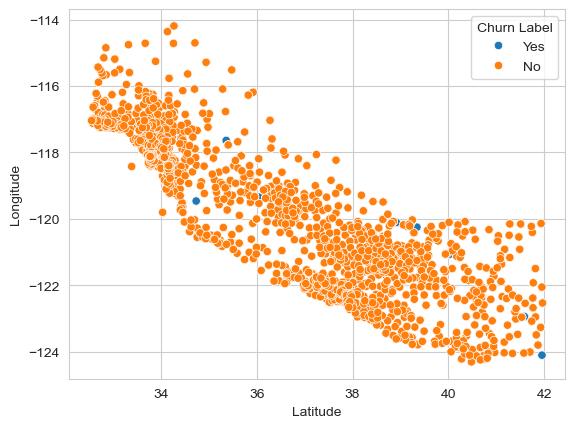

In [117]:
sns.scatterplot(data=cust_data, x='Latitude', y='Longitude', hue='Churn Label')

- these lat ad long may be meaningless so we may drop them later when dealing with features.

In [118]:
# zip code:
pd.crosstab(cust_data['Zip Code'], cust_data['Churn Label'], normalize='index')*100

Churn Label,No,Yes
Zip Code,,
90001,60.0,40.0
90002,80.0,20.0
90003,80.0,20.0
90004,60.0,40.0
90005,40.0,60.0
...,...,...
96145,75.0,25.0
96146,100.0,0.0
96148,50.0,50.0


In [119]:
cust_data['Zip Code'].nunique()

1652

- here also we can see that Zip code will be no use for us cause is  categorical calumn and it has a lot of unique values, we may also drop it. 

# Key EDA Insights :
- Customers with month-to-month contract churn significantly more.
- Customers with shorter tenure show higher churn rates.
- Higher monthly charges are associated with increased churn.
- Customers lacking tech support or online security or online backup tend to churn more frequently.
- long-term contarct customers are more stable and loyal.
- Customers with manual Electronic check payement method exhibit significantly higher churn rates compared to customers with autmatic renew payment method.
- Customer with Inernet Service of Fiber Optic has the most churn rate.
- Customers that have or live with dependents like children and parent have lower rate of churn.

# 5- Data Cleaning :

# 5.1- Dealing with mising values:

In [121]:
cust_data.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [123]:
(cust_data.isnull().sum() / len(cust_data))*100

CustomerID            0.000000
Count                 0.000000
Country               0.000000
State                 0.000000
City                  0.000000
Zip Code              0.000000
Lat Long              0.000000
Latitude              0.000000
Longitude             0.000000
Gender                0.000000
Senior Citizen        0.000000
Partner               0.000000
Dependents            0.000000
Tenure Months         0.000000
Phone Service         0.000000
Multiple Lines        0.000000
Internet Service      0.000000
Online Security       0.000000
Online Backup         0.000000
Device Protection     0.000000
Tech Support          0.000000
Streaming TV          0.000000
Streaming Movies      0.000000
Contract              0.000000
Paperless Billing     0.000000
Payment Method        0.000000
Monthly Charges       0.000000
Total Charges         0.156183
Churn Label           0.000000
Churn Value           0.000000
Churn Score           0.000000
CLTV                  0.000000
Churn Re

- For total charge : since the proportion of missing data in total charges is vry small, the affected row will be removed to preserve dataset consistency without significatly impacting the dataset size.
- For Churn Reason : first the percentage of missing value is 73% which is already probelmatic, and also i notice that this information answer the question "Why the customer churned", and this information only available after churn happened.
- a model should predict churm before it happens so this culumn provide a data leakage , and we should definitely drop it completely.  

In [124]:
# droping the feature Churn Reason:
cust_data.drop('Churn Reason', axis=1, inplace=True)

In [125]:
# now we drop the mising raws for totale charges:
cust_data.dropna(inplace=True)

In [126]:
cust_data.isnull().sum()

CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
dtype: int64

# 5.2- Dealing With Incorrect Data Types : 

In [127]:
cust_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7032 non-null   object 
 1   Count              7032 non-null   int64  
 2   Country            7032 non-null   object 
 3   State              7032 non-null   object 
 4   City               7032 non-null   object 
 5   Zip Code           7032 non-null   int64  
 6   Lat Long           7032 non-null   object 
 7   Latitude           7032 non-null   float64
 8   Longitude          7032 non-null   float64
 9   Gender             7032 non-null   object 
 10  Senior Citizen     7032 non-null   object 
 11  Partner            7032 non-null   object 
 12  Dependents         7032 non-null   object 
 13  Tenure Months      7032 non-null   int64  
 14  Phone Service      7032 non-null   object 
 15  Multiple Lines     7032 non-null   object 
 16  Internet Service   7032 non-n

- every column has the right data type, after we dealt with Total charges.

# 5.3- Dealing With Duplicate Rows :

In [128]:
cust_data.duplicated().sum()

np.int64(0)

- there are no duplicated rows, we all good here too.

# 5.4- Checking Inconsistent Values :

In [129]:
cust_data.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV'],
      dtype='object')

In [147]:
cust_data['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

- After checking all the column for inconsistency, everything looks good for now so we are done with this part.

# 5.5- Dealing and finding unnecessary Columns :

In [148]:
# 1- CustomerID:
cust_data.drop('CustomerID', axis=1, inplace=True)

- this is just an identifier, useless feature.

In [149]:
# 2- Count , Country, State :
cust_data.drop(['Count', 'Country', 'State'], axis=1, inplace=True)

- they only have one unique value for all rows, zero variance, completly useless.

In [150]:
# 3- 'City', 'Zip Code','Lat Long', 'Latitude', 'Longitude' :
cust_data.drop(['City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude'], axis=1, inplace=True)

- high cardinality categorical features, they have +1000 categories, very difficult to encode, sparse features  and likly overfitting.
- we coul've also use target encoding or cluster regions or aggregates cites , for now the safest move is to drop them and keep models clean. 

In [152]:
# 4- Churn Label:
cust_data[['Churn Label', 'Churn Value']].head()

,Churn Label,Churn Value
0,Yes,1
1,Yes,1
2,Yes,1
3,Yes,1
4,Yes,1


- we can tell that this is a duplicated not usefull column snce we have Churn Value already binary with 1= yes and 0=no, we should drop the Churn Label and keep only the Churn Value.

In [153]:
cust_data.drop('Churn Label', axis=1, inplace=True)

In [154]:
# 5- Churn Score:
cust_data.drop('Churn Score', axis=1, inplace=True)

- this is a DATA LEAKAGE
- predictive score generated using churn related logic.
- this is nor raw customer data, it is already engineered predictive information and using it would make the model unrealsitic.
- i dont ant our model to rely on it.

In [155]:
# 6- CLTV :
cust_data.drop('CLTV', axis=1, inplace=True)

- this one is little bit tricky, cause it could be not leakage cause but it contains indirectly tenure , spending and customer value estimate, which may strongly encode churm behavior already.
- business- generated predictive features may introduce indirect data leakage and reduce model interpretability.
- i want to keep model project clean and more realistic and based on raw customer attributes.

# 6- Feature engineering :

# Dealing With Categorical Features :

In [157]:
# All remaining columns after cleaning:
cust_data.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='object')

In [176]:
# Only categrical and string columns:
cust_data.select_dtypes(exclude='number').columns

Index(['Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Payment Method'],
      dtype='object')

- 1- columns like : 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing', we use binry encoding for yes=1 and no=0

In [192]:
cust_data['Gender'] = cust_data['Gender'].map({
    'Male':1,
    'Female':0
})

In [193]:
binary_cols = [
    'Senior Citizen',
    'Partner',
    'Dependents',
    'Phone Service',
    'Paperless Billing'
]

for col in binary_cols:
    cust_data[col] = cust_data[col].map({
        'Yes':1,
        'No':0
    })

In [194]:
cust_data.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
1,0,0,0,1,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
2,0,0,0,1,8,1,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,99.65,820.50,1
3,0,0,1,1,28,1,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,1,Electronic check,104.80,3046.05,1
4,1,0,0,1,49,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Bank transfer (automatic),103.70,5036.30,1


2- for Internet Service: Nominal categorical variable, with no atural order, so we use one-hot encoding.

In [197]:
# we create dummies variables:
intrnet_dummies = pd.get_dummies(cust_data['Internet Service'], dtype=int, drop_first=True)

In [198]:
# we concatinate it with the original data frame:
cust_data = pd.concat([cust_data, intrnet_dummies], axis=1)

In [199]:
# we drop the original Internet Service column :
cust_data.drop('Internet Service', axis=1, inplace=True)

3- for columns like : 'Online Security', 'Online Backup', 'Device Protection' .... : 
- we have Yes No nd NO internet Service , we eill first replace No internet with no because not hving internet means the service also is absent.
- then we map yes and no to 1 and 0.

In [208]:
cust_data.select_dtypes(exclude='number').columns

Index(['Multiple Lines', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Payment Method'],
      dtype='object')

In [209]:
cust_data['Online Backup'].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [210]:
#
service_cols = [
    'Online Security',
    'Online Backup',
    'Device Protection',
    'Tech Support',
    'Streaming TV',
    'Streaming Movies'
]

for col in service_cols :
    cust_data[col] = cust_data[col].replace(
        'No internet service',
        'No'
    )

    cust_data[col] = cust_data[col].map({
        'Yes':1,
        'No':0
    })

4- same thing fr multiple line just related to Phone service:

In [212]:
cust_data['Multiple Lines'].unique()

array(['No', 'Yes', 'No phone service'], dtype=object)

In [213]:
#first we replace :
cust_data['Multiple Lines'] = cust_data['Multiple Lines'].replace(
    'No phone service',
    'No'
)

#second we map to 0 and 1:
cust_data['Multiple Lines'] = cust_data['Multiple Lines'].map({
    'Yes':1,
    'No':0
})

4- For the column : Contract
- this feature actualy has ordering, longer contract imply stronger commitment.
- so this is : ORDINAL CATEGORICAL Variable , we use Ordinal Encoding for it.

In [215]:
cust_data['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [216]:
cust_data['Contract'] = cust_data['Contract'].map({
    'Month-to-month':0,
    'One year':1,
    'Two year':2
})

6- for the column : Payment Method
- it's a NOMINAL CATEGORICAL variable, no real order between them , so we use one-hot-encoding with.

In [218]:
cust_data['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [220]:
cust_data = pd.get_dummies(cust_data, columns=['Payment Method'], dtype=int, drop_first=True)

7- last i want to do is group tenure while keeping the original too:

In [222]:
cust_data['Tenure Months'].unique()

array([ 2,  8, 28, 49, 10,  1, 47, 17,  5, 34, 11, 15, 18,  9,  7, 12, 25,
       68, 55, 37,  3, 27, 20,  4, 58, 53, 13,  6, 19, 59, 16, 52, 24, 32,
       38, 54, 43, 63, 21, 69, 22, 61, 60, 48, 40, 23, 39, 35, 56, 65, 33,
       30, 45, 46, 62, 70, 50, 44, 71, 26, 14, 41, 66, 64, 29, 42, 67, 51,
       31, 57, 36, 72])

In [224]:
# first we create the new feature:
cust_data['Tenure Group'] = pd.cut(
    cust_data['Tenure Months'],
    bins=[0,12,24,48,72],
    labels=['New', 'Short-Term', 'Medium-Term', 'Long-Term']
)

In [226]:
# we encode it :
cust_data['Tenure Group'] = cust_data['Tenure Group'].map({
    'New':0,
    'Short-Term':1,
    'Medium-Term':2,
    'Long-Term':3
})

In [228]:
# final data frame:
cust_data.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,...,Paperless Billing,Monthly Charges,Total Charges,Churn Value,Fiber optic,No,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure Group
0,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,1,0,0,0,0,1,0
1,0,0,0,1,2,1,0,0,0,0,...,1,70.70,151.65,1,1,0,0,1,0,0
2,0,0,0,1,8,1,1,0,0,1,...,1,99.65,820.50,1,1,0,0,1,0,0
3,0,0,1,1,28,1,1,0,0,1,...,1,104.80,3046.05,1,1,0,0,1,0,2
4,1,0,0,1,49,1,1,0,1,1,...,1,103.70,5036.30,1,1,0,0,0,0,3


# 7- Data Preprocessing :

# 7.1- Prepares the features and the label Data:

In [229]:
X = cust_data.drop('Churn Value', axis=1)

In [231]:
y = cust_data['Churn Value']

# 7.2- Split Dataset to train and test data:

In [233]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 7.3- Scaling the features:

In [234]:
# crate the scaler object:
scaler = StandardScaler()

In [235]:
# train the scaler to the train data :
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [236]:
# transform both the traning data nd testing data:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8- Modeling:

# 8.1- LOGISTIC REGRESSION :

In [237]:
# initiating the model :
log_model = LogisticRegression()

In [238]:
# Train the model with scaled data:
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [239]:
log_preds = log_model.predict(X_test_scaled)

In [240]:
log_preds

array([0, 0, 0, ..., 0, 0, 0], shape=(2110,))

In [241]:
## evaluating the model prediction:
print(classification_report(y_test, log_preds))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1522
           1       0.71      0.60      0.65       588

    accuracy                           0.82      2110
   macro avg       0.78      0.75      0.76      2110
weighted avg       0.81      0.82      0.81      2110



In [242]:
print(confusion_matrix(y_test, log_preds))

[[1375  147]
 [ 234  354]]


- Logistic Regression produced the best overall balance between accuracy, precision, and recall. The model demonstrated strong generalization capability while remaining highly interpretable. It successfully identified a large portion of churn customers while maintaining strong overall classification performance.

# 8.2- KNN :

In [243]:
# first we test for best K neighbors:
error_rate = []

for i in range(1,40):
    knn_i = KNeighborsClassifier(n_neighbors=i)
    knn_i.fit(X_train_scaled, y_train)
    pred_i = knn_i.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

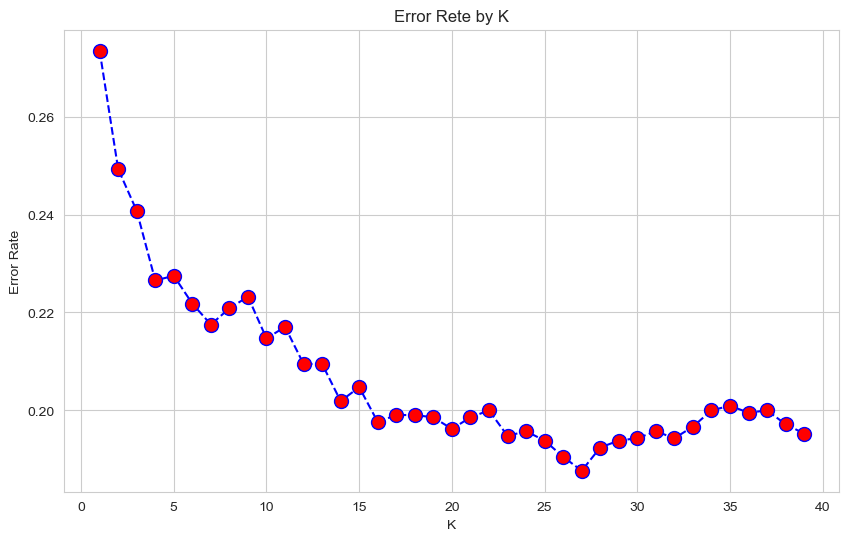

In [244]:
## now we visualize the knn error rate to trytake the one that minimize it :
plt.figure(figsize=(10,6))
plt.plot(range(1,40), error_rate, color='blue', ls='--', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rete by K')
plt.xlabel('K')
plt.ylabel('Error Rate')

- we can see after ploting that the best K that minimize the the error rate is K=27
- so we are going now to create the model with this K . 

In [246]:
#creating the model:
knn_model = KNeighborsClassifier(n_neighbors=27)

In [247]:
#training the model:
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,27
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [248]:
knn_preds = knn_model.predict(X_test_scaled)

In [249]:
knn_preds

array([0, 0, 0, ..., 1, 0, 0], shape=(2110,))

In [250]:
# evaluating the model predictions:
print(classification_report(y_test, knn_preds))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1522
           1       0.68      0.62      0.65       588

    accuracy                           0.81      2110
   macro avg       0.77      0.75      0.76      2110
weighted avg       0.81      0.81      0.81      2110



In [251]:
print(confusion_matrix(y_test, knn_preds))

[[1349  173]
 [ 223  365]]


- KNN achieved competitive performance and produced the highest recall for churn customers among all evaluated models. This suggests the model was slightly better at identifying customers likely to churn, although it remained less interpretable and computationally heavier compared to Logistic Regression.

# 8.3- Support Vectur Mchine :

In [252]:
svc_model = SVC()

In [253]:
# training the model :
svc_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [254]:
svc_preds = svc_model.predict(X_test_scaled)

In [255]:
svc_preds

array([0, 0, 0, ..., 0, 0, 0], shape=(2110,))

In [256]:
# evaluation :
print(classification_report(y_test, svc_preds))

              precision    recall  f1-score   support

           0       0.84      0.92      0.87      1522
           1       0.71      0.54      0.61       588

    accuracy                           0.81      2110
   macro avg       0.77      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110



In [257]:
print(confusion_matrix(y_test, svc_preds))

[[1394  128]
 [ 271  317]]


In [258]:
## let's try to tune the model more to see better result:
param_grid = {
    'C':[0.1, 1, 10, 100, 1000],
    'gamma':[1, 0.1, 0.01, 0.001, 0.0001]
}

In [260]:
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)

In [261]:
grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END .....................................C=0.1, gamma=1; total time=   1.4s
[CV] END .....................................C=0.1, gamma=1; total time=   1.3s
[CV] END .....................................C=0.1, gamma=1; total time=   1.3s
[CV] END .....................................C=0.1, gamma=1; total time=   1.3s
[CV] END .....................................C=0.1, gamma=1; total time=   1.4s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.7s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.8s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.9s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.9s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.8s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.6s
[CV] END ..................................C=0.

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [262]:
print(grid.best_params_)

{'C': 100, 'gamma': 0.001}


In [263]:
better_svc_model = grid.best_estimator_

In [264]:
## lets predict with this new model:
new_svc_preds = better_svc_model.predict(X_test_scaled)

In [265]:
# evaluating the new model :
print(classification_report(y_test, new_svc_preds))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1522
           1       0.72      0.51      0.59       588

    accuracy                           0.81      2110
   macro avg       0.77      0.72      0.73      2110
weighted avg       0.80      0.81      0.80      2110



In [266]:
print(confusion_matrix(y_test, new_svc_preds))

[[1403  119]
 [ 289  299]]


- Support Vector Machine achieved strong overall accuracy and classification stability. However, despite hyperparameter tuning, the model struggled to improve recall for churn customers, indicating that optimization focused more heavily on the majority class.

# 8.4- Decission Tree :

In [268]:
# we dont need scaling for this one :
tree_model = DecisionTreeClassifier()

In [269]:
# we use non scaled data:
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [270]:
tree_preds = tree_model.predict(X_test)

In [271]:
# evaluation :
print(classification_report(y_test, tree_preds))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1522
           1       0.51      0.49      0.50       588

    accuracy                           0.73      2110
   macro avg       0.66      0.65      0.66      2110
weighted avg       0.72      0.73      0.73      2110



In [272]:
print(confusion_matrix(y_test, tree_preds))

[[1247  275]
 [ 300  288]]


- The Decision Tree model produced the weakest overall performance among the evaluated models. Although highly interpretable, the model appeared more prone to overfitting and demonstrated weaker generalization capability on unseen data.

# 8.5- Random Forest :

In [273]:
rfc_model = RandomForestClassifier(n_estimators=200)

In [274]:
# we use not scaled not :
rfc_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [275]:
rfc_preds = rfc_model.predict(X_test)

In [276]:
# evaluation :
print(classification_report(y_test, rfc_preds))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1522
           1       0.67      0.51      0.58       588

    accuracy                           0.80      2110
   macro avg       0.75      0.71      0.72      2110
weighted avg       0.78      0.80      0.79      2110



<Axes: >

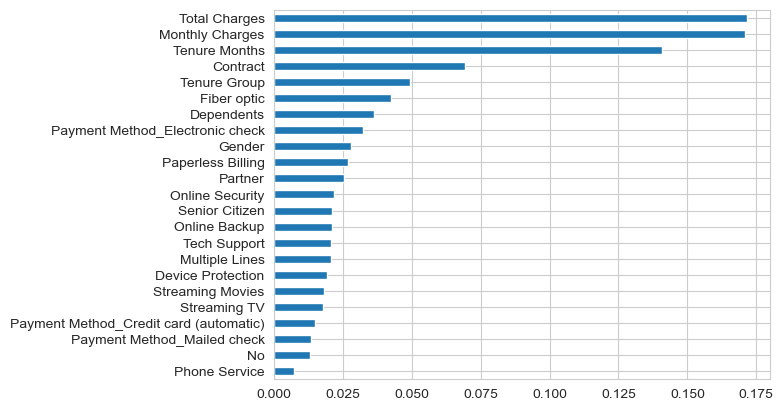

In [277]:
# we plot the feature importance too :
importance = pd.Series(rfc_model.feature_importances_, index=X_train.columns)
importance.sort_values().plot(kind='barh')

- We can se here the model sort the importance of the features and it seems that it reals almost the same analysis insights we found and we observed in EDA section .

- Random Forest delivered strong overall classification accuracy and reduced overfitting compared to a single Decision Tree. However, the model still struggled to identify churn customers effectively, producing relatively lower recall for the minority class.

# 8.6- Deep Learning - Nueral Network:

In [278]:
# we need to use scled data for nuearal network.

In [279]:
# first we see the shape 
X.shape

(7032, 23)

In [280]:
## creating an early stop : so we dont overfit the model.
early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')

In [281]:
# we have 23 colums:
# creating the model :
nt_model = Sequential()

nt_model.add(Dense(23, activation='relu'))
nt_model.add(Dropout(0.3))

nt_model.add(Dense(12, activation='relu'))
nt_model.add(Dropout(0.3))

nt_model.add(Dense(1, activation='sigmoid'))

nt_model.compile(optimizer='adam', loss='binary_crossentropy')


In [282]:
## we train the model :
nt_model.fit(x=X_train_scaled, y=y_train, validation_data=(X_test_scaled, y_test), epochs=100, callbacks=[early_stop])

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.6334 - val_loss: 0.4593
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4945 - val_loss: 0.4321
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4617 - val_loss: 0.4251
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4492 - val_loss: 0.4193
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4458 - val_loss: 0.4188
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4330 - val_loss: 0.4159
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4266 - val_loss: 0.4166
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4341 - val_loss: 0.4161
Epoch 9/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4276 - val_loss: 0.4154
Epoch 10/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4271 - val_loss: 0.4156
Epoch 11/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4210 - val_loss: 0.4109
Epoch 12/100
154/154 ━━━━━━━━━━━━━━━━━━━━

In [283]:
losses = pd.DataFrame(nt_model.history.history)

<Axes: >

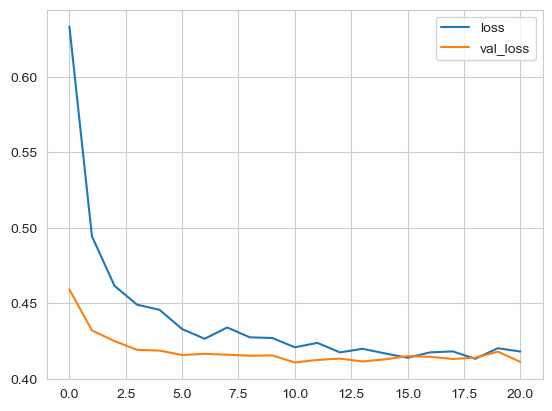

In [284]:
losses.plot()

In [285]:
nt_preds = nt_model.predict(X_test_scaled)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [286]:
nt_preds

array([[0.01181926],
       [0.14800902],
       [0.42766932],
       ...,
       [0.30359188],
       [0.06663621],
       [0.10360517]], shape=(2110, 1), dtype=float32)

In [287]:
nt_preds_clases = (nt_preds > 0.5).astype(int)

In [288]:
nt_preds_clases

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2110, 1))

In [289]:
# evaluation :
print(classification_report(y_test, nt_preds_clases))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1522
           1       0.69      0.54      0.61       588

    accuracy                           0.81      2110
   macro avg       0.76      0.72      0.74      2110
weighted avg       0.80      0.81      0.80      2110



In [290]:
print(confusion_matrix(y_test, nt_preds_clases))

[[1381  141]
 [ 270  318]]


- The Neural Network model achieved competitive performance comparable to classical machine learning algorithms. The use of dropout layers and early stopping helped reduce overfitting and improve model generalization.

# 9- Conclusions:

# Key Business Insights :
- Customers with month-to-month contracts showed significantly higher churn rates.
- Customers with shorter tenure were more likely to churn.
- Higher monthly charges correlated with increased churn probability.
- Logistic Regression produced the best balance between interpretability and predictive performance.

# Business Recomendations :
- Focus retention campaigns on new customers.
- Encourage customers toward longer-term contracts.
- Improve support services for high-risk customer segments.
- Monitor customers with high monthly charges and short tenure.